<a href="https://colab.research.google.com/github/nickpartner/mammogram/blob/feature%2Fabdulaziz-dataset/mammogram_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This dataset is from the NHS open acces https://nhsx.github.io/open-source-imaging-data-sets/ providing datasets for use of research

The idea is to

# Setup Environment

In [47]:
# mount gdrive so we can download there and persist

from google.colab import drive
import os

# Mount Google Drive
drive.mount('/gdrive', force_remount=True)

base_path = '/gdrive/MyDrive/assignment/abdulaziz'

Mounted at /gdrive


## Grab the Data

In [3]:
# This data set comes from the King Abdulaziz University dataset

# The current study aims to build the first digitalized mammogram dataset for breast cancer in Saudi Arabia,
# depend on the BI-RADS categories, to solve the availability problem of local public datasets by collecting,
# categorizing, and annotating mammogram images, supporting the medical field by providing physicians with different
# diagnosed cases especially in Saudi Arabia

# https://www.kaggle.com/datasets/asmaasaad/king-abdulaziz-university-mammogram-dataset/data

The dataset is setup based on the BI-RADS classification system. This is is a 7 point scale when reading a mamogram.

https://www.wellwomen.co.za/helpie_faq/what-is-the-meaning-of-the-word-bi-rads-which-i-have-read-on-my-report/

The dataset contains

Character of background tissue:
 1 - Negative
 3 - Probably Benign [ 2 is benign ]
 4 - Suspicious
 5 - Highly Suggestive

Absent is
 0 - Scan is problematic and needs redoing
 2 - Benign
 6 - confirmed through biopsy



In [4]:
# Grab the data from kagglehub into

import kagglehub

# Download latest version
download_path = kagglehub.dataset_download("asmaasaad/king-abdulaziz-university-mammogram-dataset", output_dir=base_path+'/base')

print("Path to dataset files:", download_path)


100%|██████████| 578M/578M [00:06<00:00, 97.1MB/s]

Extracting files...


Path to dataset files: /gdrive/MyDrive/assignment/abdulaziz/base


## Generate the metadata

In [6]:
import requests
import pandas as pd

In [7]:
# use the directory listings to construct the labelling information

import os

b1 = os.listdir(download_path+'/BIRAD1/b1')
b3 = os.listdir(download_path+'/Birad3/b3')
b4 = os.listdir(download_path+'/Birad4/b4')
b5 = os.listdir(download_path+'/Birad5/Birad5')


b1_df = pd.DataFrame(b1, columns=['filename'])
b1_df['BIRAD'] = 1
b1_df['path'] = 'BIRAD1/b1/'+b1_df['filename']

b3_df = pd.DataFrame(b3, columns=['filename'])
b3_df['BIRAD'] = 3
b3_df['path'] = 'Birad3/b3/'+b3_df['filename']

b4_df = pd.DataFrame(b4, columns=['filename'])
b4_df['BIRAD'] = 4
b4_df['path'] = 'Birad4/b4/'+b4_df['filename']

b5_df = pd.DataFrame(b5, columns=['filename'])
b5_df['BIRAD'] = 5
b5_df['path'] = 'Birad5/Birad5/'+b5_df['filename']


all_images = pd.concat([b1_df, b3_df, b4_df, b5_df])

all_images.head()


,filename,BIRAD,path
0,2013_BC000541_ CC_L.jpg,1,BIRAD1/b1/2013_BC000541_ CC_L.jpg
1,2013_BC000541_ CC_R.jpg,1,BIRAD1/b1/2013_BC000541_ CC_R.jpg
2,2013_BC000541_ MLO_L.jpg,1,BIRAD1/b1/2013_BC000541_ MLO_L.jpg
3,2013_BC000541_ MLO_R.jpg,1,BIRAD1/b1/2013_BC000541_ MLO_R.jpg
4,2013_BC001201_ CC_L.jpg,1,BIRAD1/b1/2013_BC001201_ CC_L.jpg


In [8]:
# as a result we will use the file names which contain the patient id and image type
# to construct the labelled data

# date_patientno_imagetype_side

metadata = all_images['filename'].str.split('_',expand=True)

#metadata.head()

# side has the image file extension after - so will split that out.
# will keep the image type at the end, just so we can check we have consistent images

metadata_end = metadata[3].str.split('.',expand=True)

labels = all_images
labels['year'] = metadata[0]
labels['patient'] = metadata[1]
labels['imaging_type'] = metadata[2]
labels['side'] = metadata_end[0]
labels['file_type'] = metadata_end[1]

labels.head()

,filename,BIRAD,path,year,patient,imaging_type,side,file_type
0,2013_BC000541_ CC_L.jpg,1,BIRAD1/b1/2013_BC000541_ CC_L.jpg,2013,BC000541,CC,L,jpg
1,2013_BC000541_ CC_R.jpg,1,BIRAD1/b1/2013_BC000541_ CC_R.jpg,2013,BC000541,CC,R,jpg
2,2013_BC000541_ MLO_L.jpg,1,BIRAD1/b1/2013_BC000541_ MLO_L.jpg,2013,BC000541,MLO,L,jpg
3,2013_BC000541_ MLO_R.jpg,1,BIRAD1/b1/2013_BC000541_ MLO_R.jpg,2013,BC000541,MLO,R,jpg
4,2013_BC001201_ CC_L.jpg,1,BIRAD1/b1/2013_BC001201_ CC_L.jpg,2013,BC001201,CC,L,jpg


## Test Paths

Even though the sample sizes aren't huge we are going to setup some sample paths to help check the code and provide examples against without iterating through 000's of image manipulations each time.

Yes, these might be a little bit path specific, but are really debug mainly

In [464]:
test_paths_b1 = ['BIRAD1/b1/2017_BC009804_ MLO_R.jpg']

test_paths_b5 = ['Birad5/Birad5/2018_BC0022025_ MLO_R.jpg']


# Data Cleaning

check for oddities and issues and remove anything prior to features and training

### duplicate images

In [10]:
## Noticed later that there are duplicate images with different BI-RADS
## they are the same patient and also manual review shows the same image
## but clipped. There are only two patients so manually removing these.
## Without a specialist to recategorise, this isn't possible.
##
## (Note: girlfriend refused to help with this despite being a doctor)

file_count = labels \
  .groupby(['filename'])['filename']\
  .count().reset_index(name='count')

duplicates = file_count \
                .loc[file_count['count']>1]


## remove duplicates - left_anti is being mean to me, so a little convoluted!

no_duplicates_join = pd.merge(labels, duplicates, on='filename', how='left') \

no_duplicates = no_duplicates_join \
                    .loc[no_duplicates_join['count'].isna()] \
                    .drop(['count'],axis=1)

display(no_duplicates)

,filename,BIRAD,path,year,patient,imaging_type,side,file_type
0,2013_BC000541_ CC_L.jpg,1,BIRAD1/b1/2013_BC000541_ CC_L.jpg,2013,BC000541,CC,L,jpg
1,2013_BC000541_ CC_R.jpg,1,BIRAD1/b1/2013_BC000541_ CC_R.jpg,2013,BC000541,CC,R,jpg
2,2013_BC000541_ MLO_L.jpg,1,BIRAD1/b1/2013_BC000541_ MLO_L.jpg,2013,BC000541,MLO,L,jpg
3,2013_BC000541_ MLO_R.jpg,1,BIRAD1/b1/2013_BC000541_ MLO_R.jpg,2013,BC000541,MLO,R,jpg
4,2013_BC001201_ CC_L.jpg,1,BIRAD1/b1/2013_BC001201_ CC_L.jpg,2013,BC001201,CC,L,jpg
...,...,...,...,...,...,...,...,...
2371,2018_BC0022603_ MLO_R.jpg,5,Birad5/Birad5/2018_BC0022603_ MLO_R.jpg,2018,BC0022603,MLO,R,jpg
2372,2018_BC005421_ CC_L.jpg,5,Birad5/Birad5/2018_BC005421_ CC_L.jpg,2018,BC005421,CC,L,jpg
2374,2018_BC005421_ MLO_L.jpg,5,Birad5/Birad5/2018_BC005421_ MLO_L.jpg,2018,BC005421,MLO,L,jpg
2376,2019_BC0024763_ CC_L.jpg,5,Birad5/Birad5/2019_BC0024763_ CC_L.jpg,2019,BC0024763,CC,L,jpg


In [11]:
## used as a final dataframe to allow for multiple cleaning steps inserted as we go!

final_labels = no_duplicates.copy()

## image xif metadata

In [ ]:
## lets avoid running this 00000 of times!

!pip install Pillow



In [92]:
# lets grab the details of the image as well as this might be useful for a bit
# of analysis - trimming, clipping etc.

# we can grab out the image type, size and format to verify

from PIL import Image

image_details = pd.DataFrame(columns=('path','type'))

for image_path in final_labels['path']:

  source_full_path = os.path.join(download_path,image_path)

  im = Image.open(source_full_path)

  im_details = pd.DataFrame({
                                'file':[im.filename],
                                'type':[im.format],
                                'width':[im.width],
                                'height':[im.height],
                                'filename':image_path.split("/")[-1]
                            })
  image_details = pd.concat([image_details, im_details])
  im.close()

image_details.head()

,path,type,file,width,height,filename
0,NaN,JPEG,/gdrive/MyDrive/assignment/abdulaziz/base/BIRA...,2816.0,3584.0,2013_BC000541_ CC_L.jpg
0,NaN,JPEG,/gdrive/MyDrive/assignment/abdulaziz/base/BIRA...,2816.0,3584.0,2013_BC000541_ CC_R.jpg
0,NaN,JPEG,/gdrive/MyDrive/assignment/abdulaziz/base/BIRA...,2816.0,3584.0,2013_BC000541_ MLO_L.jpg
0,NaN,JPEG,/gdrive/MyDrive/assignment/abdulaziz/base/BIRA...,2816.0,3584.0,2013_BC000541_ MLO_R.jpg
0,NaN,JPEG,/gdrive/MyDrive/assignment/abdulaziz/base/BIRA...,2816.0,3584.0,2013_BC001201_ CC_L.jpg


## image orientation

Left and right breast images have a different orientation due to the way that the images are made. The images with 'L' have the chest wall against the left of the image and empty space to the right and 'R' has the inverse. This may cause some problems with CNN which works on slices and the slices will appear very differently on ordering so aligning orientation may boost.

Note that this will apply to both CC and MLO.

It might be that later we need to duplicate or retranspose these to increase sample sizes, but for now it provides some consistency (particularly for the next steps)

In [437]:
from PIL import Image
import os

# will flip all of the rights to left.

# Define the output directory for processed images
# we have a base_path and then relative folder for feature

output_dir = os.path.join(base_path, 'feature/mirrored')

#print(output_dir)

for image_path in final_labels['path']:

  # read from the download path as kaggle likes to cache
  # so it isn't always where you tell it to go!

  source_full_path = os.path.join(download_path,image_path)

  #print('source '+source_full_path)

  im = Image.open(source_full_path)

  # Get the side of the image (L or R) from final_labels
  # and flip the image only for Right side (to ensure all pointing one way)

  image_side = final_labels.loc[final_labels['path'] == image_path, 'side'].iloc[0]

  if (image_side == 'R'):
    im = im.transpose(method=Image.Transpose.FLIP_LEFT_RIGHT)

  # Construct the full path for the output file
  # and create intermediate or it fails

  #print(output_dir)

  output_path = os.path.join(output_dir, image_path)
  os.makedirs(output_path[:output_path.rindex(os.path.sep)], exist_ok=True)
  im.save(output_path)

  im.close()

## Image Trimming

Its quickly observable that the images contain different sizes. Some of this is due to white space, some because of breast size. Initially look to trim all of the black space out before normalising the images a little

<Axes: xlabel='aspect'>

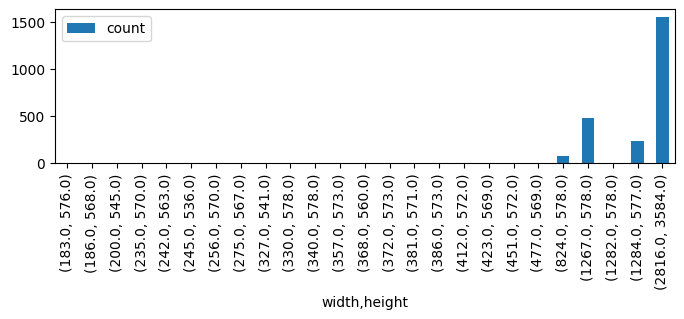

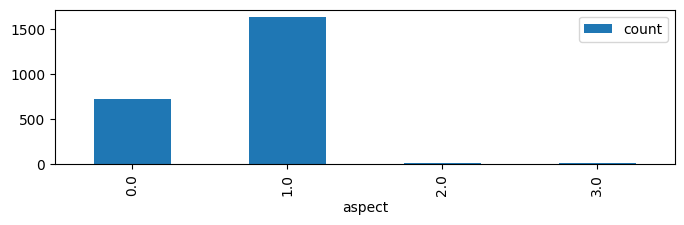

In [95]:
import matplotlib.pyplot as plt

# grab a quick freq diagram of the images to show the problem of size

image_sizes = pd.merge(image_details, final_labels, on='filename',how='left')

image_size_freq = image_sizes \
                      .groupby(['width','height'])['BIRAD'] \
                      .agg(['count'])


image_size_freq.plot.bar(figsize=(8,2))


# have a look at the aspect ratios so we can review trimming issues

image_sizes['aspect'] = round(image_sizes['height']/image_sizes['width'])

image_size_aspect = image_sizes \
                      .groupby(['aspect'])['aspect'] \
                      .agg(['count'])

# DEBUG display(trimmed_image_details)

image_size_aspect.plot.bar(figsize=(8,2))


this is particularly annoying as this long tail when you look at it by BI-RADS is actually almost all BIRAD 5 which is small enough.

The first issue is these BIRAD5 images are all trimmed to remove the "whitespace" on the image.

The other is largely that of size which. As a result, whilst its tempting to perhaps exclude the small images - this can't be done. Equally resizing the other images would squeeze the image to kill all future work. The best way therefore is to initially trim the images to remove the space and then to resize to a similar aspect so as not to lose information.


['Birad5/Birad5/2018_BC0022025_ MLO_R.jpg']


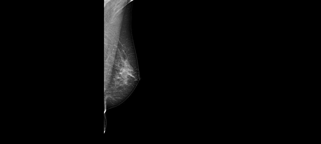

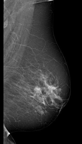

In [467]:
## this gives a couple of examples of this
## yes I have resized, this is just to show the padding which exists
## on the BIRAD5 images

from PIL import Image, ImageShow

(width, height) = (im.width // 4, im.height // 4)

print(test_paths_b5)

image_path = os.path.join(base_path, 'feature/mirrored')

im = Image.open(image_path+'/'+test_paths_b1[0])
(width, height) = (im.width // 4, im.height // 4)
display(im.resize((width, height)))

im = Image.open(image_path+'/'+test_paths_b5[0])
(width, height) = (im.width // 4, im.height // 4)
display(im.resize((width, height)))

So what we are going to do is pre-process all the other images to trim all blacks out to the left. Now we have flipped all the Right images this should be a little easier

In [104]:
# get the images
# work out the height, and sum all black pixels across every vertical
# once we have that resize to remove all of this just leaving the breast only

from PIL import Image
import matplotlib.pyplot as plt

input_dir = os.path.join(base_path, 'feature/mirrored')
output_dir = os.path.join(base_path, 'feature/trimmed')


for image_path in final_labels['path']:

  source_full_path = os.path.join(input_dir,image_path)

  im = Image.open(source_full_path)

  # its an RBG, but this is much simpler given its greyscale anyway
  im_grey = im.convert('L')

  # grab this as a pixel array so we can just iterate through it
  # and find the widths where we are finding all blacks and trim
  # two points of note where this has been adjusted:

  # - the value of "black" has been adjusted to "near black" for quality
  #   this is to avoid noise.

  # - we aren't looking at the overall width. After performing analysis
  #   after the first time on sizes, there are some images where the scan
  #   has small white band on the top right where it looks like the image
  #   was scanned with a very slight rotation, (2013_BC004406_ MLO_L) so
  #   ignoring the last 10px which solves, and doesn't damage other images

  # NOTE: getpixel is VERY slow - there will be a better way, just
  #       just can't find it right now. Have a feeling something is
  #       is being throttled as it generated quickly enough initially

  blacks_column_count = []

  for x in range(0,im_grey.width-20):
    black_count = 0

    for y in range(0,im_grey.height-1):

      #print(im_grey.getpixel((x,y)))

      if (im_grey.getpixel((x,y)) > 30):
        black_count = black_count + 1
        #print(im_grey.getpixel((x,y)))

    if (black_count > 0):
      blacks_column_count.append(x)

  #DEBUG: print(blacks_column_count)

  # do the cropping of the image based on where we don't blacks in a
  # vertical. This will trim both sides which we see in images

  crop_left = min(blacks_column_count)
  crop_right = max(blacks_column_count)
  im_cropped = im.crop((crop_left,0,crop_right,im_grey.height))

  output_path = os.path.join(output_dir, image_path)
  os.makedirs(output_path[:output_path.rindex(os.path.sep)], exist_ok=True)
  im_cropped.save(output_path)

  im_cropped.close()
  im.close()

KeyboardInterrupt: 

<Axes: xlabel='aspect'>

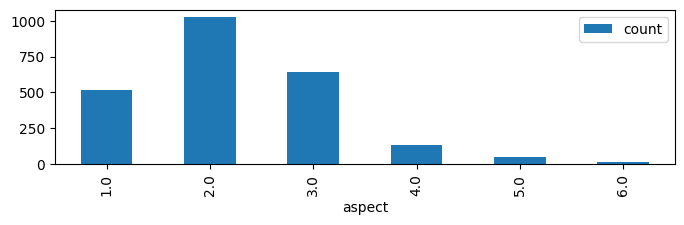

In [76]:
# test again after trimming

from PIL import Image
import matplotlib.pyplot as plt

trimmed_image_details = pd.DataFrame(columns=('path','type'))

for image_path in final_labels['path']:

  source_full_path = os.path.join(base_path,'feature/trimmed',image_path)

  im = Image.open(source_full_path)

  im_details = pd.DataFrame({
                                'file':[im.filename],
                                'width':[im.width],
                                'height':[im.height],
                            })
  trimmed_image_details = pd.concat([trimmed_image_details, im_details])
  im.close()


# grab a quick freq diagram of the images to show the problem of size

trimmed_image_details['aspect'] = round(trimmed_image_details['height']/trimmed_image_details['width'])

trimmed_image_size_freq = trimmed_image_details \
                      .groupby(['aspect'])['aspect'] \
                      .agg(['count'])

# DEBUG display(trimmed_image_details)

trimmed_image_size_freq.plot.bar(figsize=(8,2))

## Normalise the sizes

Whilst its possible to add CNN filters of abnormal sizes now that that images are more common, we can go ahead and just resize these.

In [111]:
# grab the images and resize to standard aspect ratio.
# following the trimming this is now around 2 on average
# as we saw which should allow for full images without sever distortion



from PIL import Image
import matplotlib.pyplot as plt

input_dir = os.path.join(base_path, 'feature/sized')
output_dir = os.path.join(base_path, 'feature/sized')

# switching to a standard size .. this makes the CNN way easier
# the distortion is very minimal by keeping the aspect ratio

normal_height = 600 ## 578 is the standard height
normal_width = 300 ## 280 is width to hit a 2:1 aspec ratio


for image_path in final_labels['path']:

  source_full_path = os.path.join(input_dir,image_path)

  im = Image.open(source_full_path)

  # resize to the chosen size. BICUBIC - high quality resample
  im_resized = im.resize((normal_width, normal_height), resample=Image.BICUBIC)

  output_path = os.path.join(output_dir, image_path)
  os.makedirs(output_path[:output_path.rindex(os.path.sep)], exist_ok=True)
  im_resized.save(output_path)

  im_resized.close()
  im.close()


# Feature Engineering

So we know that there are a few different areas to look at here.


1. The category of the breast tissue

If the tissue is dense rather than fatty then the breast images will show up with more "white". Obviously at a simple level we are looking for white masses in a darker image then this is more problematic and needs to be factored in

2. Potentially we may need to adjust the images. The actual breast image will be a

3. We have for every patient 4 images - Left and Right breast and two different scans - MLO and CC. We would expect a correlation of results here. There ought to be a strong correlation between the scans on the same breast and a smaller correlation between breasts (since there are genetic factors if you have it in one breast there is a higher chance in the other)

4. We may also want to aid recognition altering the orientation of the images so that left points the same way as right.

## Breast Density

When we are looking at mammograms one of the other large features we need to consider is the type of tissue. Fat will show as darker in the images, and tissue is bright. This is particularly important when looking for a tumor which as a set of dense tissue cells will appear more apparent against a dark background.

Whilst some datasets have this already this dataset does not. In order to provide an input we will generate a feature to try and estimate this. It will be a feature per image. The way we will do this is by reviewing the histogram of the images.

In [75]:
# we can grab out the image type, size and format to verify
# Then we can start to assess the % of remaining pixels. This isn't completely ideal. There are some images where the chest
# cavity is partially visible (and a couple where obviously an implant is visible), but should give a better set of data to assess this

from PIL import Image
import matplotlib.pyplot as plt

density_data = []

for image_path in final_labels['path']:

  source_full_path = os.path.join(base_path,'feature/trimmed',image_path)

  im = Image.open(source_full_path)

  # the images are actually RBG so converting this to greyscale to make this more sensible

  im_grey = im.convert('L')
  grey_freq = im_grey.getcolors()
  im.close()
  df_greyfreq = pd.DataFrame(grey_freq, columns=['frequency','colour'])
  #print(df_greyfreq)

  # most of the image is actually black, so really we want to exclude this - or general noise of the image
  # so filter out black or near - [0-10] as greyscale which is being used for the trimming.

  pixels_notblack = df_greyfreq.loc[df_greyfreq['colour']>30].copy()

  # create a binned frequency table with % across the bins to normalise across different
  # image sizes and also breast sizes

  pixels_notblack["greyscale_bin"] = pd.qcut(pixels_notblack["colour"], q=10)
  df_sumbins = pixels_notblack.groupby(['greyscale_bin'],observed=False).sum()

  # in order to normalise over the total pixels. We have different sizes of every factor
  # image, breast in image (we have not excluded blacks), breast this should normalise this feature

  total_pixels_grey = pixels_notblack['frequency'].sum()
  df_sumbins_prc = round(100*(df_sumbins['frequency']/total_pixels_grey),2)
  df_sumbins_prc['image_path'] = image_path

  density_data.append(df_sumbins_prc)


# Final analysis before Execution


## Distribution of BIRADs

In [51]:
# quick check of the images here. There aren't a *lot* of images which are positive in fairness.
# This is a bit of a risk in the efficacy if we are looking for features. Probably a better approach
# then is to look at algorithms which are trained to look for outliers and use the BIRAD 1 as the
# training dataset initially. Given 3,4 are suspicious we need to look how to treat these

final_labels.groupby('BIRAD')['BIRAD'].count()

,BIRAD
BIRAD,
1,1863
3,387
4,100
5,20


# Model Execution

Because of the distribution of the training data we are going to look for outliers in the base data. In this case its easier to train then the data on "normal" and run against exceptions, rather than a classifier model where we require large amount of data. We aren't so much looking to partition the space or look for features, but to search for particular abnormalies.

This also fits with the procedure where medically only a biopsy is a confirmation - everything is effectively just searching for something unusual to review further.

As a result a supervised Fully Convolutional Data Description approach would intuitively seem to be the best approach here. The level of explainability in this area also would in real life provide

## Feature dataset

## Training partitioning

Start by doing the normal partitioning of the training set

In [138]:
from torchvision import transforms, datasets
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import ToTensor


# we are trying to detect abnormalities, so training only on BIRAD1 as our large "normal" set
# stripping off b1 as it expects the classification in the folder structure when loading in

source_full_path = os.path.join(base_path,'feature/sized/BIRAD1')

# we've pre-processed everything carefully, so just a case of changing to tensor on load
toTensor=transforms.ToTensor()

train_dataset = torchvision.datasets.ImageFolder(root=source_full_path, transform=toTensor)
train_loader = DataLoader(dataset=train_dataset, batch_size=10, shuffle=True)

## Create the model

In [159]:
import torch.nn as nn
import torchvision
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()

        ## convert to a 2d matrix.

        ## We have reduced to greyscale so 1 channel and keeps computation lower
        ## Created images which are 300x600
        ## kernel_size - going for 10.
        ## this should give a 29x58 output

        image_height = 600
        image_width = 300

        # lets reduce computation further as there is a lot to do!
        # possibly efficacy may drop, HPO may show better
        # this should output a 30x15

        self.conv1 = nn.Conv2d(in_channels=3, kernel_size=(20,20), stride=10, out_channels=1)

        ## now add a pooling layer. At 5x5 this should now get me an output
        ## of 6x3

        self.pool = nn.MaxPool2d(kernel_size=5, stride=5)

        # a couple of nets

        self.fc1 = nn.Linear(in_features=(55), out_features=10)
        #self.fc2 = nn.Linear(10, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        #x = F.relu(self.fc2(x))
        #x = self.fc3(x)
        return x


net = Net()

In [152]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)

In [ ]:
for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

In [ ]:
model_path = base_path+'/model/fcnn.torch'
torch.save(net.state_dict(), model_path)

## Test Inference

# Analysis